In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

API_KEY    = "746a30f11c7a4614b7878680ed13a7e8"
UTC_OFFSET = 3

print("SMC Detector — XAU/USD H1")
print("=" * 40)
print("Components:")
print("  1. Swing High/Low detection")
print("  2. Break of Structure (BOS)")
print("  3. Change of Character (CHoCH)")
print("  4. Order Block (OB) identification")
print("  5. Fair Value Gap (FVG) detection")

SMC Detector — XAU/USD H1
Components:
  1. Swing High/Low detection
  2. Break of Structure (BOS)
  3. Change of Character (CHoCH)
  4. Order Block (OB) identification
  5. Fair Value Gap (FVG) detection


In [2]:
def fetch_twelvedata(symbol="XAU/USD", interval="1h",
                     outputsize=5000):
    url    = "https://api.twelvedata.com/time_series"
    params = {
        "symbol"    : symbol,
        "interval"  : interval,
        "outputsize": outputsize,
        "apikey"    : API_KEY,
        "format"    : "JSON"
    }
    r    = requests.get(url, params=params)
    data = r.json()

    if data.get("status") == "error":
        print(f"Error: {data.get('message')}")
        return None

    df = pd.DataFrame(data["values"])
    df["datetime"] = pd.to_datetime(df["datetime"])
    df = df.set_index("datetime").sort_index()
    df = df.astype(float)
    df.columns = [c.lower() for c in df.columns]
    return df

print("Loading XAU/USD H1...")
df = fetch_twelvedata("XAU/USD", "1h", 5000)

print(f"Loaded  : {len(df)} bars")
print(f"Range   : {df.index[0].date()} to {df.index[-1].date()}")
print(f"Current : ${df['close'].iloc[-1]:.2f}")

Loading XAU/USD H1...
Loaded  : 5000 bars
Range   : 2025-12-17 to 2026-07-16
Current : $4033.47


Swing detection complete
  Swing highs : 220
  Swing lows  : 237
  Per month   : 65.3 swing points


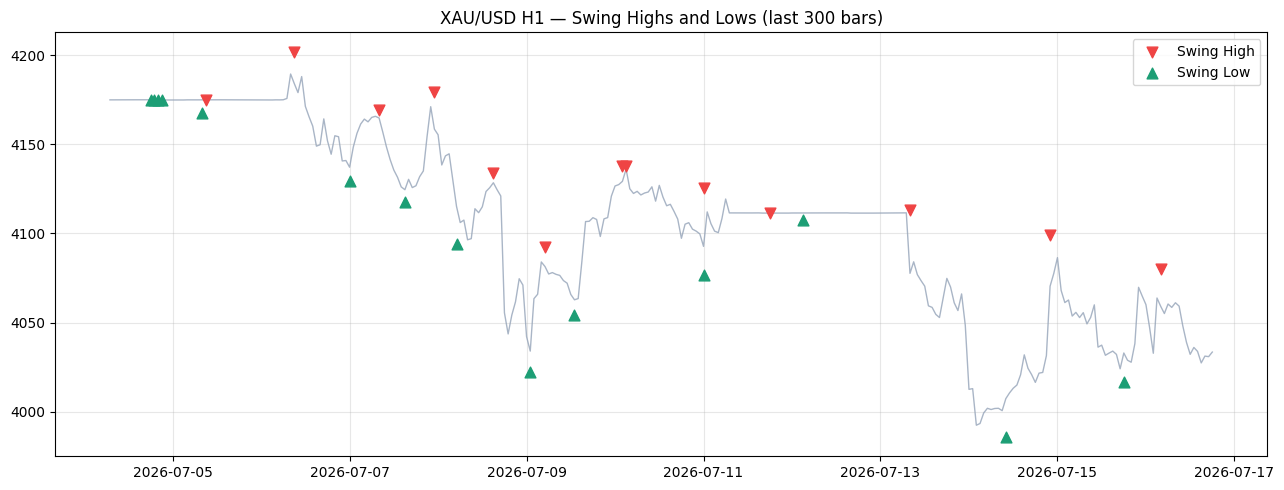

In [3]:
def detect_swings(df, lookback=10):
    """
    Detect swing highs and lows.
    A swing high = highest high in lookback bars
    on both sides. Same for swing low.
    """
    highs = df['high']
    lows  = df['low']
    n     = len(df)

    swing_high = pd.Series(False, index=df.index)
    swing_low  = pd.Series(False, index=df.index)
    sh_price   = pd.Series(np.nan, index=df.index)
    sl_price   = pd.Series(np.nan, index=df.index)

    for i in range(lookback, n - lookback):
        # Swing high — highest in window
        window_h = highs.iloc[i-lookback:i+lookback+1]
        if highs.iloc[i] == window_h.max():
            swing_high.iloc[i] = True
            sh_price.iloc[i]   = highs.iloc[i]

        # Swing low — lowest in window
        window_l = lows.iloc[i-lookback:i+lookback+1]
        if lows.iloc[i] == window_l.min():
            swing_low.iloc[i] = True
            sl_price.iloc[i]  = lows.iloc[i]

    df['swing_high']    = swing_high
    df['swing_low']     = swing_low
    df['sh_price']      = sh_price
    df['sl_price']      = sl_price

    return df

df = detect_swings(df, lookback=10)

n_sh = df['swing_high'].sum()
n_sl = df['swing_low'].sum()

print(f"Swing detection complete")
print(f"  Swing highs : {n_sh}")
print(f"  Swing lows  : {n_sl}")
print(f"  Per month   : {(n_sh+n_sl)/7:.1f} swing points")

# Plot recent swings
fig, ax = plt.subplots(figsize=(13, 5))
recent = df.iloc[-300:]
ax.plot(recent.index, recent['close'],
        color='#94a3b8', lw=1, alpha=0.8)
ax.scatter(recent[recent['swing_high']].index,
           recent[recent['swing_high']]['high'],
           color='#ef4444', marker='v', s=60,
           zorder=5, label='Swing High')
ax.scatter(recent[recent['swing_low']].index,
           recent[recent['swing_low']]['low'],
           color='#1D9E75', marker='^', s=60,
           zorder=5, label='Swing Low')
ax.set_title('XAU/USD H1 — Swing Highs and Lows (last 300 bars)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

BOS/CHoCH detection complete
  Bullish BOS  : 27
  Bearish BOS  : 20
  Bullish CHoCH: 26
  Bearish CHoCH: 26


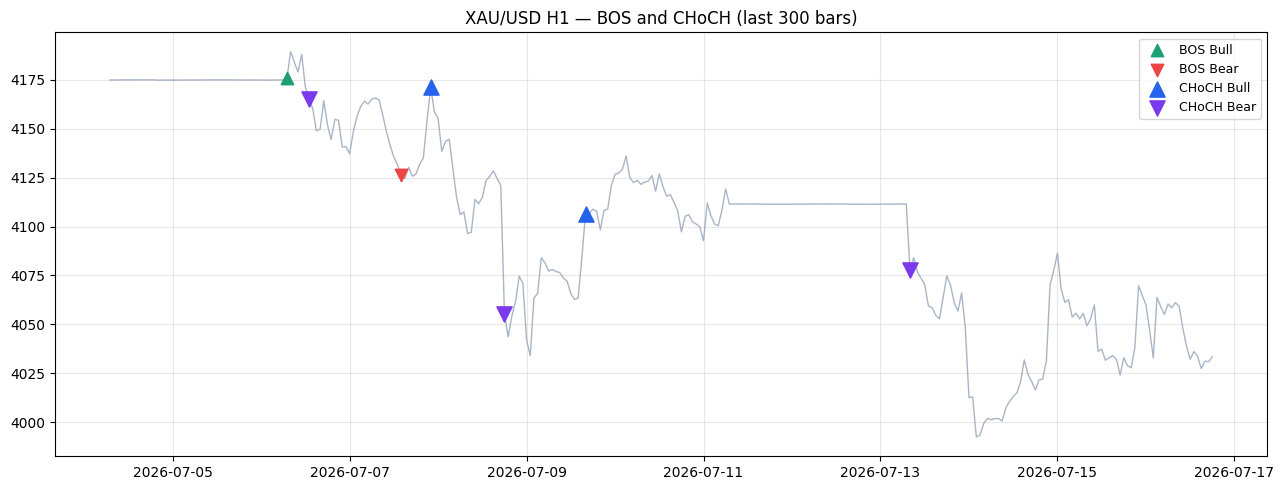

In [4]:
def detect_bos_choch(df):
    """
    Break of Structure (BOS) — price breaks previous swing
    in the SAME direction as current trend (continuation)

    Change of Character (CHoCH) — price breaks previous swing
    in the OPPOSITE direction (potential reversal)
    """
    bos_bull   = pd.Series(False, index=df.index)
    bos_bear   = pd.Series(False, index=df.index)
    choch_bull = pd.Series(False, index=df.index)
    choch_bear = pd.Series(False, index=df.index)
    bos_level  = pd.Series(np.nan, index=df.index)

    # Track last confirmed swing points
    last_sh = None  # last swing high price
    last_sl = None  # last swing low price
    trend   = None  # current trend: 'bull' or 'bear'

    for i in range(1, len(df)):
        # Update last swing points
        if df['swing_high'].iloc[i]:
            last_sh = df['sh_price'].iloc[i]
        if df['swing_low'].iloc[i]:
            last_sl = df['sl_price'].iloc[i]

        if last_sh is None or last_sl is None:
            continue

        close = df['close'].iloc[i]
        high  = df['high'].iloc[i]
        low   = df['low'].iloc[i]

        # Bullish BOS — close breaks above last swing high
        if close > last_sh:
            if trend == 'bull':
                # Same direction = BOS (continuation)
                bos_bull.iloc[i]  = True
                bos_level.iloc[i] = last_sh
            else:
                # Opposite direction = CHoCH (reversal)
                choch_bull.iloc[i] = True
                bos_level.iloc[i]  = last_sh
            trend  = 'bull'
            last_sh = None  # reset after break

        # Bearish BOS — close breaks below last swing low
        elif close < last_sl:
            if trend == 'bear':
                # Same direction = BOS (continuation)
                bos_bear.iloc[i]  = True
                bos_level.iloc[i] = last_sl
            else:
                # Opposite direction = CHoCH (reversal)
                choch_bear.iloc[i] = True
                bos_level.iloc[i]  = last_sl
            trend  = 'bear'
            last_sl = None  # reset after break

    df['bos_bull']   = bos_bull
    df['bos_bear']   = bos_bear
    df['choch_bull'] = choch_bull
    df['choch_bear'] = choch_bear
    df['bos_level']  = bos_level

    return df

df = detect_bos_choch(df)

print(f"BOS/CHoCH detection complete")
print(f"{'='*45}")
print(f"  Bullish BOS  : {df['bos_bull'].sum()}")
print(f"  Bearish BOS  : {df['bos_bear'].sum()}")
print(f"  Bullish CHoCH: {df['choch_bull'].sum()}")
print(f"  Bearish CHoCH: {df['choch_bear'].sum()}")
print(f"{'='*45}")

# Plot recent BOS/CHoCH
fig, ax = plt.subplots(figsize=(13, 5))
recent = df.iloc[-300:]

ax.plot(recent.index, recent['close'],
        color='#94a3b8', lw=1, alpha=0.8)

# BOS markers
ax.scatter(recent[recent['bos_bull']].index,
           recent[recent['bos_bull']]['close'],
           color='#1D9E75', marker='^', s=80,
           zorder=5, label='BOS Bull')
ax.scatter(recent[recent['bos_bear']].index,
           recent[recent['bos_bear']]['close'],
           color='#ef4444', marker='v', s=80,
           zorder=5, label='BOS Bear')

# CHoCH markers
ax.scatter(recent[recent['choch_bull']].index,
           recent[recent['choch_bull']]['close'],
           color='#2563eb', marker='^', s=120,
           zorder=5, label='CHoCH Bull')
ax.scatter(recent[recent['choch_bear']].index,
           recent[recent['choch_bear']]['close'],
           color='#7c3aed', marker='v', s=120,
           zorder=5, label='CHoCH Bear')

ax.set_title('XAU/USD H1 — BOS and CHoCH (last 300 bars)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Order Block detection complete
  Bullish OBs : 44
  Bearish OBs : 44
  Total OBs   : 88


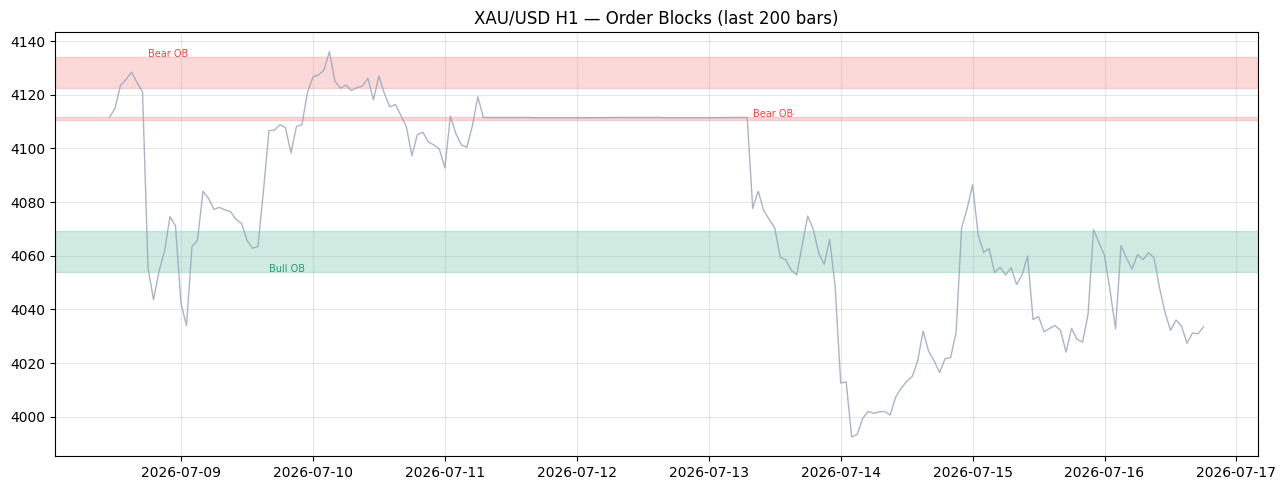

In [5]:
def detect_order_blocks(df, lookback=5):
    """
    Order Block detection:
    Bullish OB = last BEARISH candle before a Bullish BOS/CHoCH
    Bearish OB = last BULLISH candle before a Bearish BOS/CHoCH

    OB remains valid until price returns to mitigate it.
    """
    bull_ob_high = pd.Series(np.nan, index=df.index)
    bull_ob_low  = pd.Series(np.nan, index=df.index)
    bear_ob_high = pd.Series(np.nan, index=df.index)
    bear_ob_low  = pd.Series(np.nan, index=df.index)
    bull_ob_date = pd.Series(pd.NaT, index=df.index)
    bear_ob_date = pd.Series(pd.NaT, index=df.index)

    for i in range(lookback, len(df)):
        # Bullish BOS or CHoCH — find last bearish candle before it
        if df['bos_bull'].iloc[i] or df['choch_bull'].iloc[i]:
            # Look back for last bearish candle
            for j in range(i-1, max(i-lookback-1, 0), -1):
                if df['close'].iloc[j] < df['open'].iloc[j]:
                    # Found bearish candle — this is the OB
                    bull_ob_high.iloc[i] = df['high'].iloc[j]
                    bull_ob_low.iloc[i]  = df['low'].iloc[j]
                    bull_ob_date.iloc[i] = df.index[j]
                    break

        # Bearish BOS or CHoCH — find last bullish candle before it
        if df['bos_bear'].iloc[i] or df['choch_bear'].iloc[i]:
            for j in range(i-1, max(i-lookback-1, 0), -1):
                if df['close'].iloc[j] > df['open'].iloc[j]:
                    # Found bullish candle — this is the OB
                    bear_ob_high.iloc[i] = df['high'].iloc[j]
                    bear_ob_low.iloc[i]  = df['low'].iloc[j]
                    bear_ob_date.iloc[i] = df.index[j]
                    break

    df['bull_ob_high'] = bull_ob_high
    df['bull_ob_low']  = bull_ob_low
    df['bear_ob_high'] = bear_ob_high
    df['bear_ob_low']  = bear_ob_low

    n_bull_ob = df['bull_ob_high'].notna().sum()
    n_bear_ob = df['bear_ob_high'].notna().sum()

    print(f"Order Block detection complete")
    print(f"{'='*45}")
    print(f"  Bullish OBs : {n_bull_ob}")
    print(f"  Bearish OBs : {n_bear_ob}")
    print(f"  Total OBs   : {n_bull_ob + n_bear_ob}")
    print(f"{'='*45}")

    # Plot recent OBs
    fig, ax = plt.subplots(figsize=(13, 5))
    recent = df.iloc[-200:]

    ax.plot(recent.index, recent['close'],
            color='#94a3b8', lw=1, alpha=0.8)

    # Draw OB boxes
    for idx, row in recent.iterrows():
        if not np.isnan(row['bull_ob_high']):
            ax.axhspan(row['bull_ob_low'], row['bull_ob_high'],
                      alpha=0.2, color='#1D9E75',
                      xmin=0, xmax=1)
            ax.annotate('Bull OB', xy=(idx, row['bull_ob_low']),
                       fontsize=7, color='#1D9E75')

        if not np.isnan(row['bear_ob_high']):
            ax.axhspan(row['bear_ob_low'], row['bear_ob_high'],
                      alpha=0.2, color='#ef4444',
                      xmin=0, xmax=1)
            ax.annotate('Bear OB', xy=(idx, row['bear_ob_high']),
                       fontsize=7, color='#ef4444')

    ax.set_title('XAU/USD H1 — Order Blocks (last 200 bars)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df

df = detect_order_blocks(df)

FVG detection complete
  Bullish FVGs : 337
  Bearish FVGs : 294
  Total FVGs   : 631
  Per month    : 90.1


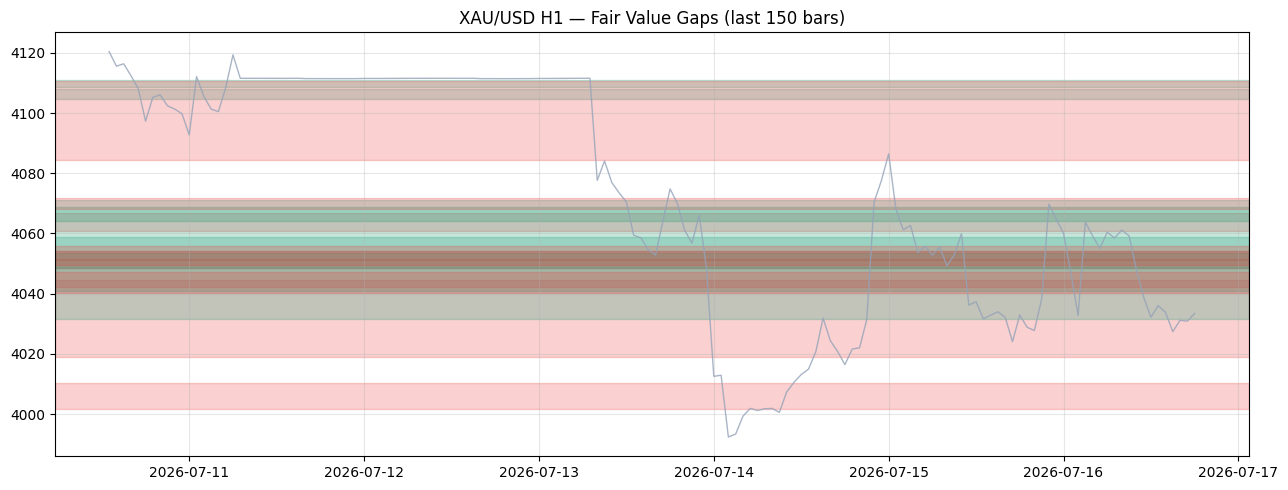

In [6]:
def detect_fvg(df, min_gap_pct=0.0005):
    """
    Fair Value Gap (FVG) detection.
    Bullish FVG: candle[i-1].high < candle[i+1].low
                 gap between bar 1 high and bar 3 low
    Bearish FVG: candle[i-1].low > candle[i+1].high
                 gap between bar 1 low and bar 3 high

    min_gap_pct: minimum gap size as % of price
                 filters out micro gaps
    """
    bull_fvg_high = pd.Series(np.nan, index=df.index)
    bull_fvg_low  = pd.Series(np.nan, index=df.index)
    bear_fvg_high = pd.Series(np.nan, index=df.index)
    bear_fvg_low  = pd.Series(np.nan, index=df.index)

    for i in range(1, len(df)-1):
        price     = df['close'].iloc[i]
        min_gap   = price * min_gap_pct

        # Bullish FVG
        gap_low  = df['high'].iloc[i-1]
        gap_high = df['low'].iloc[i+1]
        if gap_high > gap_low and (gap_high - gap_low) > min_gap:
            bull_fvg_low.iloc[i]  = gap_low
            bull_fvg_high.iloc[i] = gap_high

        # Bearish FVG
        gap_high2 = df['low'].iloc[i-1]
        gap_low2  = df['high'].iloc[i+1]
        if gap_high2 > gap_low2 and \
           (gap_high2 - gap_low2) > min_gap:
            bear_fvg_high.iloc[i] = gap_high2
            bear_fvg_low.iloc[i]  = gap_low2

    df['bull_fvg_high'] = bull_fvg_high
    df['bull_fvg_low']  = bull_fvg_low
    df['bear_fvg_high'] = bear_fvg_high
    df['bear_fvg_low']  = bear_fvg_low

    n_bull = df['bull_fvg_high'].notna().sum()
    n_bear = df['bear_fvg_high'].notna().sum()

    print(f"FVG detection complete")
    print(f"{'='*45}")
    print(f"  Bullish FVGs : {n_bull}")
    print(f"  Bearish FVGs : {n_bear}")
    print(f"  Total FVGs   : {n_bull + n_bear}")
    print(f"  Per month    : {(n_bull+n_bear)/7:.1f}")
    print(f"{'='*45}")

    # Plot recent FVGs
    fig, ax = plt.subplots(figsize=(13, 5))
    recent  = df.iloc[-150:]

    ax.plot(recent.index, recent['close'],
            color='#94a3b8', lw=1, alpha=0.8)

    for idx, row in recent.iterrows():
        if not np.isnan(row['bull_fvg_high']):
            ax.axhspan(row['bull_fvg_low'],
                       row['bull_fvg_high'],
                       alpha=0.25, color='#1D9E75')
        if not np.isnan(row['bear_fvg_high']):
            ax.axhspan(row['bear_fvg_low'],
                       row['bear_fvg_high'],
                       alpha=0.25, color='#ef4444')

    ax.set_title('XAU/USD H1 — Fair Value Gaps (last 150 bars)')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df

df = detect_fvg(df, min_gap_pct=0.0005)

In [7]:
def generate_smc_signals(df):
    """
    SMC Entry Logic:
    BUY  — CHoCH bullish OR BOS bullish
           + price retraces to bullish OB zone
           + bullish FVG nearby for confluence
    SELL — CHoCH bearish OR BOS bearish
           + price retraces to bearish OB zone
           + bearish FVG nearby for confluence
    """
    buy_signal  = pd.Series(False, index=df.index)
    sell_signal = pd.Series(False, index=df.index)

    # Track active OBs
    active_bull_ob = None  # (high, low)
    active_bear_ob = None

    for i in range(1, len(df)):
        row = df.iloc[i]

        # Update active OBs when new ones form
        if not np.isnan(row['bull_ob_high']):
            active_bull_ob = (row['bull_ob_high'],
                              row['bull_ob_low'])
        if not np.isnan(row['bear_ob_high']):
            active_bear_ob = (row['bear_ob_high'],
                              row['bear_ob_low'])

        # BUY signal — price retraces into bullish OB
        # after a bullish BOS or CHoCH
        if active_bull_ob is not None:
            ob_high, ob_low = active_bull_ob
            in_bull_ob = (row['low']  <= ob_high and
                          row['close'] >= ob_low)

            # Check for nearby bullish FVG
            recent_bull_fvg = df['bull_fvg_high'].iloc[
                max(0,i-10):i].notna().any()

            if in_bull_ob:
                buy_signal.iloc[i]  = True
                active_bull_ob      = None  # OB used

        # SELL signal — price retraces into bearish OB
        if active_bear_ob is not None:
            ob_high, ob_low = active_bear_ob
            in_bear_ob = (row['high']  >= ob_low and
                          row['close'] <= ob_high)

            # Check for nearby bearish FVG
            recent_bear_fvg = df['bear_fvg_high'].iloc[
                max(0,i-10):i].notna().any()

            if in_bear_ob:
                sell_signal.iloc[i] = True
                active_bear_ob      = None  # OB used

    df['smc_buy']  = buy_signal
    df['smc_sell'] = sell_signal

    n_buy  = buy_signal.sum()
    n_sell = sell_signal.sum()

    print(f"SMC Signals generated")
    print(f"{'='*45}")
    print(f"  BUY signals  : {n_buy}")
    print(f"  SELL signals : {n_sell}")
    print(f"  Total        : {n_buy + n_sell}")
    print(f"  Per month    : {(n_buy+n_sell)/7:.1f}")
    print(f"{'='*45}")

    return df

df = generate_smc_signals(df)

SMC Signals generated
  BUY signals  : 36
  SELL signals : 37
  Total        : 73
  Per month    : 10.4


In [8]:
# ATR for SL/TP sizing
def atr_calc(high, low, close, length=14):
    tr = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low  - close.shift(1)).abs()
    ], axis=1).max(axis=1)
    return tr.rolling(length).mean()

df['atr'] = atr_calc(df['high'], df['low'], df['close'])

SL_MULT  = 1.0
TP1_MULT = 2.0

results = []

for i in range(len(df)):
    row = df.iloc[i]

    if not (row['smc_buy'] or row['smc_sell']):
        continue

    direction = 'LONG' if row['smc_buy'] else 'SHORT'
    entry     = row['close']
    atr_val   = row['atr']
    bar_time  = df.index[i]

    if np.isnan(atr_val) or atr_val == 0:
        continue

    if direction == 'LONG':
        sl  = entry - atr_val * SL_MULT
        tp1 = entry + atr_val * TP1_MULT
    else:
        sl  = entry + atr_val * SL_MULT
        tp1 = entry - atr_val * TP1_MULT

    outcome = None; exit_price = None
    exit_bar = None; max_bars = 48

    for j in range(i+1, min(i+1+max_bars, len(df))):
        future = df.iloc[j]
        if direction == 'LONG':
            if future['low'] <= sl:
                outcome='LOSS'; exit_price=sl
                exit_bar=j; break
            elif future['high'] >= tp1:
                outcome='WIN'; exit_price=tp1
                exit_bar=j; break
        else:
            if future['high'] >= sl:
                outcome='LOSS'; exit_price=sl
                exit_bar=j; break
            elif future['low'] <= tp1:
                outcome='WIN'; exit_price=tp1
                exit_bar=j; break

    if outcome is None:
        outcome    = 'BE'
        exit_price = df.iloc[min(i+max_bars,
                     len(df)-1)]['close']
        exit_bar   = min(i+max_bars, len(df)-1)

    risk = abs(entry - sl)
    if risk == 0:
        continue
    if outcome == 'WIN':
        actual_r = abs(exit_price - entry) / risk
    elif outcome == 'LOSS':
        actual_r = -abs(exit_price - entry) / risk
    else:
        actual_r = (exit_price - entry) / risk \
                   if direction == 'LONG' \
                   else (entry - exit_price) / risk

    h = (bar_time.hour + UTC_OFFSET) % 24
    if 13 <= h < 17:   session = 'Overlap'
    elif 8 <= h < 17:  session = 'London'
    elif 13 <= h < 22: session = 'NY'
    elif 0 <= h < 9:   session = 'Tokyo'
    else:              session = 'Off'

    results.append({
        'date'     : bar_time,
        'direction': direction,
        'entry'    : round(entry, 2),
        'sl'       : round(sl, 2),
        'tp1'      : round(tp1, 2),
        'exit'     : round(exit_price, 2),
        'outcome'  : outcome,
        'actual_r' : round(float(actual_r), 3),
        'session'  : session,
        'atr'      : round(atr_val, 2)
    })

results_df = pd.DataFrame(results)

wins    = (results_df['outcome']=='WIN').sum()
losses  = (results_df['outcome']=='LOSS').sum()
be      = (results_df['outcome']=='BE').sum()
wr      = wins / len(results_df)
avg_w   = results_df[results_df['outcome']=='WIN']['actual_r'].mean()
avg_l   = results_df[results_df['outcome']=='LOSS']['actual_r'].mean()
exp     = (wr * avg_w) + ((1-wr) * avg_l)
total_r = results_df['actual_r'].sum()

print(f"\n{'='*55}")
print(f"  SMC MECHANICAL BACKTEST — XAU/USD H1")
print(f"{'='*55}")
print(f"  Total signals  : {len(results_df)}")
print(f"  Wins/Losses/BE : {wins}/{losses}/{be}")
print(f"  Win rate       : {wr:.1%}")
print(f"  Avg win        : +{avg_w:.2f}R")
print(f"  Avg loss       : {avg_l:.2f}R")
print(f"  Expectancy     : {exp:.3f}R per trade")
print(f"  Total R        : {total_r:.2f}R")
print(f"{'='*55}")

print(f"\n  BY DIRECTION:")
for d in ['LONG','SHORT']:
    sub = results_df[results_df['direction']==d]
    if len(sub) == 0: continue
    dwr = (sub['outcome']=='WIN').mean()
    der = sub['actual_r'].mean()
    print(f"  {d:<8} n:{len(sub):>3}  WR:{dwr:.0%}  "
          f"Avg R:{der:>+.2f}  Total:{sub['actual_r'].sum():.1f}R")

print(f"\n  BY SESSION:")
for s in results_df['session'].unique():
    sub = results_df[results_df['session']==s]
    swr = (sub['outcome']=='WIN').mean()
    ser = sub['actual_r'].mean()
    print(f"  {s:<10} n:{len(sub):>3}  WR:{swr:.0%}  "
          f"Avg R:{ser:>+.2f}  Total:{sub['actual_r'].sum():.1f}R")


  SMC MECHANICAL BACKTEST — XAU/USD H1
  Total signals  : 72
  Wins/Losses/BE : 22/50/0
  Win rate       : 30.6%
  Avg win        : +2.00R
  Avg loss       : -1.00R
  Expectancy     : -0.083R per trade
  Total R        : -6.00R

  BY DIRECTION:
  LONG     n: 36  WR:31%  Avg R:-0.08  Total:-3.0R
  SHORT    n: 36  WR:31%  Avg R:-0.08  Total:-3.0R

  BY SESSION:
  NY         n:  7  WR:14%  Avg R:-0.57  Total:-4.0R
  Tokyo      n: 28  WR:32%  Avg R:-0.04  Total:-1.0R
  London     n: 22  WR:27%  Avg R:-0.18  Total:-4.0R
  Off        n:  4  WR:25%  Avg R:-0.25  Total:-1.0R
  Overlap    n: 11  WR:45%  Avg R:+0.36  Total:4.0R


In [9]:
# Rebuild LIP-SIM signals on same dataframe
def ema(series, length):
    return series.ewm(span=length, adjust=False).mean()

def rsi_calc(series, length=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(length).mean()
    loss  = (-delta.clip(upper=0)).rolling(length).mean()
    rs    = gain / loss
    return 100 - (100 / (1 + rs))

def adx_calc(high, low, close, length=14):
    tr   = pd.concat([
        high - low,
        (high - close.shift(1)).abs(),
        (low  - close.shift(1)).abs()
    ], axis=1).max(axis=1)
    atr_ = tr.rolling(length).mean()
    up   = high.diff()
    down = -low.diff()
    dm_p = pd.Series(np.where((up>down)&(up>0), up, 0),
                     index=high.index)
    dm_m = pd.Series(np.where((down>up)&(down>0), down, 0),
                     index=high.index)
    di_p = 100 * dm_p.rolling(length).mean() / atr_
    di_m = 100 * dm_m.rolling(length).mean() / atr_
    dx   = 100 * (di_p - di_m).abs() / (di_p + di_m)
    return dx.rolling(length).mean()

# LIP-SIM indicators
df['ema_fast'] = ema(df['close'], 8)
df['ema_mid']  = ema(df['close'], 21)
df['ema_slow'] = ema(df['close'], 89)
df['rsi']      = rsi_calc(df['close'], 14)
df['adx']      = adx_calc(df['high'], df['low'],
                           df['close'], 14)
macd_l = ema(df['close'], 8) - ema(df['close'], 17)
macd_s = macd_l.ewm(span=9, adjust=False).mean()
df['macd_l'] = macd_l
df['macd_s'] = macd_s

# LIP-SIM conditions
df['bull_trend'] = (df['ema_fast'] > df['ema_mid']) & \
                   (df['ema_fast'] > df['ema_slow'])
df['bear_trend'] = (df['ema_fast'] < df['ema_mid']) & \
                   (df['ema_fast'] < df['ema_slow'])
df['rsi_bull']   = (df['rsi'] > 50) & (df['rsi'] < 80)
df['rsi_bear']   = (df['rsi'] < 50) & (df['rsi'] > 20)
df['macd_bull']  = df['macd_l'] > df['macd_s']
df['macd_bear']  = df['macd_l'] < df['macd_s']
df['has_trend']  = df['adx'] >= 15

# Combined signal — SMC entry + LIP-SIM confirmation
df['combined_buy']  = (df['smc_buy']  &
                       df['bull_trend'] &
                       df['rsi_bull']   &
                       df['macd_bull']  &
                       df['has_trend'])

df['combined_sell'] = (df['smc_sell'] &
                       df['bear_trend'] &
                       df['rsi_bear']   &
                       df['macd_bear']  &
                       df['has_trend'])

n_buy  = df['combined_buy'].sum()
n_sell = df['combined_sell'].sum()

print(f"{'='*50}")
print(f"  SMC + LIP-SIM COMBINED SIGNALS")
print(f"{'='*50}")
print(f"  BUY signals  : {n_buy}")
print(f"  SELL signals : {n_sell}")
print(f"  Total        : {n_buy + n_sell}")
print(f"  Per month    : {(n_buy+n_sell)/7:.1f}")
print(f"{'='*50}")

  SMC + LIP-SIM COMBINED SIGNALS
  BUY signals  : 12
  SELL signals : 10
  Total        : 22
  Per month    : 3.1


In [10]:
results_combined = []

for i in range(len(df)):
    row = df.iloc[i]

    if not (row['combined_buy'] or row['combined_sell']):
        continue

    direction = 'LONG' if row['combined_buy'] else 'SHORT'
    entry     = row['close']
    atr_val   = row['atr']
    bar_time  = df.index[i]

    if np.isnan(atr_val) or atr_val == 0:
        continue

    if direction == 'LONG':
        sl  = entry - atr_val * SL_MULT
        tp1 = entry + atr_val * TP1_MULT
    else:
        sl  = entry + atr_val * SL_MULT
        tp1 = entry - atr_val * TP1_MULT

    outcome = None; exit_price = None
    exit_bar = None; max_bars = 48

    for j in range(i+1, min(i+1+max_bars, len(df))):
        future = df.iloc[j]
        if direction == 'LONG':
            if future['low'] <= sl:
                outcome='LOSS'; exit_price=sl
                exit_bar=j; break
            elif future['high'] >= tp1:
                outcome='WIN'; exit_price=tp1
                exit_bar=j; break
        else:
            if future['high'] >= sl:
                outcome='LOSS'; exit_price=sl
                exit_bar=j; break
            elif future['low'] <= tp1:
                outcome='WIN'; exit_price=tp1
                exit_bar=j; break

    if outcome is None:
        outcome    = 'BE'
        exit_price = df.iloc[min(i+max_bars,
                     len(df)-1)]['close']

    risk = abs(entry - sl)
    if risk == 0:
        continue

    if outcome == 'WIN':
        actual_r = abs(exit_price - entry) / risk
    elif outcome == 'LOSS':
        actual_r = -abs(exit_price - entry) / risk
    else:
        actual_r = (exit_price - entry) / risk \
                   if direction == 'LONG' \
                   else (entry - exit_price) / risk

    h = (bar_time.hour + UTC_OFFSET) % 24
    if 13 <= h < 17:   session = 'Overlap'
    elif 8 <= h < 17:  session = 'London'
    elif 13 <= h < 22: session = 'NY'
    elif 0 <= h < 9:   session = 'Tokyo'
    else:              session = 'Off'

    results_combined.append({
        'date'     : bar_time,
        'direction': direction,
        'entry'    : round(entry, 2),
        'sl'       : round(sl, 2),
        'tp1'      : round(tp1, 2),
        'exit'     : round(exit_price, 2),
        'outcome'  : outcome,
        'actual_r' : round(float(actual_r), 3),
        'session'  : session,
        'atr'      : round(atr_val, 2)
    })

rc_df = pd.DataFrame(results_combined)

if len(rc_df) == 0:
    print("No completed trades")
else:
    wins   = (rc_df['outcome']=='WIN').sum()
    losses = (rc_df['outcome']=='LOSS').sum()
    be     = (rc_df['outcome']=='BE').sum()
    wr     = wins / len(rc_df)
    avg_w  = rc_df[rc_df['outcome']=='WIN']['actual_r'].mean()
    avg_l  = rc_df[rc_df['outcome']=='LOSS']['actual_r'].mean()
    exp    = (wr * avg_w) + ((1-wr) * avg_l)
    total_r = rc_df['actual_r'].sum()

    print(f"\n{'='*55}")
    print(f"  SMC + LIP-SIM COMBINED BACKTEST")
    print(f"{'='*55}")
    print(f"  Total signals  : {len(rc_df)}")
    print(f"  Wins/Losses/BE : {wins}/{losses}/{be}")
    print(f"  Win rate       : {wr:.1%}")
    print(f"  Avg win        : +{avg_w:.2f}R")
    print(f"  Avg loss       : {avg_l:.2f}R")
    print(f"  Expectancy     : {exp:.3f}R per trade")
    print(f"  Total R        : {total_r:.2f}R")
    print(f"{'='*55}")

    print(f"\n  BY DIRECTION:")
    for d in ['LONG','SHORT']:
        sub = rc_df[rc_df['direction']==d]
        if len(sub) == 0: continue
        dwr = (sub['outcome']=='WIN').mean()
        der = sub['actual_r'].mean()
        print(f"  {d:<8} n:{len(sub):>3}  WR:{dwr:.0%}  "
              f"Avg R:{der:>+.2f}  "
              f"Total:{sub['actual_r'].sum():.1f}R")

    print(f"\n  BY SESSION:")
    for s in rc_df['session'].unique():
        sub = rc_df[rc_df['session']==s]
        swr = (sub['outcome']=='WIN').mean()
        ser = sub['actual_r'].mean()
        print(f"  {s:<10} n:{len(sub):>3}  WR:{swr:.0%}  "
              f"Avg R:{ser:>+.2f}  "
              f"Total:{sub['actual_r'].sum():.1f}R")


  SMC + LIP-SIM COMBINED BACKTEST
  Total signals  : 22
  Wins/Losses/BE : 10/12/0
  Win rate       : 45.5%
  Avg win        : +2.00R
  Avg loss       : -1.00R
  Expectancy     : 0.364R per trade
  Total R        : 8.00R

  BY DIRECTION:
  LONG     n: 12  WR:50%  Avg R:+0.50  Total:6.0R
  SHORT    n: 10  WR:40%  Avg R:+0.20  Total:2.0R

  BY SESSION:
  Tokyo      n: 14  WR:43%  Avg R:+0.29  Total:4.0R
  Off        n:  2  WR:50%  Avg R:+0.50  Total:1.0R
  Overlap    n:  3  WR:33%  Avg R:+0.00  Total:0.0R
  London     n:  1  WR:100%  Avg R:+2.00  Total:2.0R
  NY         n:  2  WR:50%  Avg R:+0.50  Total:1.0R


In [11]:
def get_session(bar_time, utc_offset=3):
    """
    Session detection using raw UTC hours from Twelve Data.
    Display labels show local time (UTC+3).
    """
    h_utc = bar_time.hour  # raw UTC from Twelve Data

    if 13 <= h_utc < 17:
        return 'Overlap (16-20 local)'
    elif 8 <= h_utc < 17:
        return 'London (11-20 local)'
    elif 13 <= h_utc < 22:
        return 'NY (16-01 local)'
    elif 0 <= h_utc < 9:
        return 'Tokyo (03-12 local)'
    else:
        return 'Off'

# Test the mapping
test_hours = [0, 3, 8, 13, 16, 20, 22]
print("Session mapping (UTC → Local UTC+3):")
print("="*50)
for h in test_hours:
    from datetime import datetime
    t       = datetime(2026, 1, 1, h, 0)
    local_h = (h + 3) % 24
    sess    = get_session(t)
    print(f"  UTC {h:02d}:00 → Local {local_h:02d}:00 → {sess}")
print("="*50)

Session mapping (UTC → Local UTC+3):
  UTC 00:00 → Local 03:00 → Tokyo (03-12 local)
  UTC 03:00 → Local 06:00 → Tokyo (03-12 local)
  UTC 08:00 → Local 11:00 → London (11-20 local)
  UTC 13:00 → Local 16:00 → Overlap (16-20 local)
  UTC 16:00 → Local 19:00 → Overlap (16-20 local)
  UTC 20:00 → Local 23:00 → NY (16-01 local)
  UTC 22:00 → Local 01:00 → Off


In [12]:
results = []

for i in range(len(df)):
    row = df.iloc[i]

    if not (row['smc_buy'] or row['smc_sell']):
        continue

    direction = 'LONG' if row['smc_buy'] else 'SHORT'
    entry     = row['close']
    atr_val   = row['atr']
    bar_time  = df.index[i]

    if np.isnan(atr_val) or atr_val == 0:
        continue

    if direction == 'LONG':
        sl  = entry - atr_val * SL_MULT
        tp1 = entry + atr_val * TP1_MULT
    else:
        sl  = entry + atr_val * SL_MULT
        tp1 = entry - atr_val * TP1_MULT

    outcome = None; exit_price = None
    exit_bar = None; max_bars = 48

    for j in range(i+1, min(i+1+max_bars, len(df))):
        future = df.iloc[j]
        if direction == 'LONG':
            if future['low'] <= sl:
                outcome='LOSS'; exit_price=sl
                exit_bar=j; break
            elif future['high'] >= tp1:
                outcome='WIN'; exit_price=tp1
                exit_bar=j; break
        else:
            if future['high'] >= sl:
                outcome='LOSS'; exit_price=sl
                exit_bar=j; break
            elif future['low'] <= tp1:
                outcome='WIN'; exit_price=tp1
                exit_bar=j; break

    if outcome is None:
        outcome    = 'BE'
        exit_price = df.iloc[min(i+max_bars,
                     len(df)-1)]['close']

    risk = abs(entry - sl)
    if risk == 0:
        continue

    if outcome == 'WIN':
        actual_r = abs(exit_price - entry) / risk
    elif outcome == 'LOSS':
        actual_r = -abs(exit_price - entry) / risk
    else:
        actual_r = (exit_price - entry) / risk \
                   if direction == 'LONG' \
                   else (entry - exit_price) / risk

    # Corrected session label
    session = get_session(bar_time)

    results.append({
        'date'     : bar_time,
        'direction': direction,
        'entry'    : round(entry, 2),
        'sl'       : round(sl, 2),
        'tp1'      : round(tp1, 2),
        'exit'     : round(exit_price, 2),
        'outcome'  : outcome,
        'actual_r' : round(float(actual_r), 3),
        'session'  : session,
        'atr'      : round(atr_val, 2)
    })

results_df = pd.DataFrame(results)

wins    = (results_df['outcome']=='WIN').sum()
losses  = (results_df['outcome']=='LOSS').sum()
be      = (results_df['outcome']=='BE').sum()
wr      = wins / len(results_df)
avg_w   = results_df[results_df['outcome']=='WIN']['actual_r'].mean()
avg_l   = results_df[results_df['outcome']=='LOSS']['actual_r'].mean()
exp     = (wr * avg_w) + ((1-wr) * avg_l)
total_r = results_df['actual_r'].sum()

print(f"\n{'='*58}")
print(f"  SMC BACKTEST — CORRECTED SESSIONS (UTC+3)")
print(f"{'='*58}")
print(f"  Total signals  : {len(results_df)}")
print(f"  Wins/Losses/BE : {wins}/{losses}/{be}")
print(f"  Win rate       : {wr:.1%}")
print(f"  Avg win        : +{avg_w:.2f}R")
print(f"  Avg loss       : {avg_l:.2f}R")
print(f"  Expectancy     : {exp:.3f}R per trade")
print(f"  Total R        : {total_r:.2f}R")
print(f"{'='*58}")

print(f"\n  BY SESSION (local time UTC+3):")
for s in results_df['session'].unique():
    sub = results_df[results_df['session']==s]
    swr = (sub['outcome']=='WIN').mean()
    ser = sub['actual_r'].mean()
    print(f"  {s:<28} n:{len(sub):>3}  "
          f"WR:{swr:.0%}  Avg R:{ser:>+.2f}  "
          f"Total:{sub['actual_r'].sum():.1f}R")


  SMC BACKTEST — CORRECTED SESSIONS (UTC+3)
  Total signals  : 72
  Wins/Losses/BE : 22/50/0
  Win rate       : 30.6%
  Avg win        : +2.00R
  Avg loss       : -1.00R
  Expectancy     : -0.083R per trade
  Total R        : -6.00R

  BY SESSION (local time UTC+3):
  Overlap (16-20 local)        n:  4  WR:25%  Avg R:-0.25  Total:-1.0R
  Tokyo (03-12 local)          n: 27  WR:26%  Avg R:-0.22  Total:-6.0R
  Off                          n:  9  WR:22%  Avg R:-0.33  Total:-3.0R
  London (11-20 local)         n: 22  WR:41%  Avg R:+0.23  Total:5.0R
  NY (16-01 local)             n: 10  WR:30%  Avg R:-0.10  Total:-1.0R


In [13]:
results_combined = []

for i in range(len(df)):
    row = df.iloc[i]

    if not (row['combined_buy'] or row['combined_sell']):
        continue

    direction = 'LONG' if row['combined_buy'] else 'SHORT'
    entry     = row['close']
    atr_val   = row['atr']
    bar_time  = df.index[i]

    if np.isnan(atr_val) or atr_val == 0:
        continue

    if direction == 'LONG':
        sl  = entry - atr_val * SL_MULT
        tp1 = entry + atr_val * TP1_MULT
    else:
        sl  = entry + atr_val * SL_MULT
        tp1 = entry - atr_val * TP1_MULT

    outcome = None; exit_price = None
    exit_bar = None; max_bars = 48

    for j in range(i+1, min(i+1+max_bars, len(df))):
        future = df.iloc[j]
        if direction == 'LONG':
            if future['low'] <= sl:
                outcome='LOSS'; exit_price=sl
                exit_bar=j; break
            elif future['high'] >= tp1:
                outcome='WIN'; exit_price=tp1
                exit_bar=j; break
        else:
            if future['high'] >= sl:
                outcome='LOSS'; exit_price=sl
                exit_bar=j; break
            elif future['low'] <= tp1:
                outcome='WIN'; exit_price=tp1
                exit_bar=j; break

    if outcome is None:
        outcome    = 'BE'
        exit_price = df.iloc[min(i+max_bars,
                     len(df)-1)]['close']

    risk = abs(entry - sl)
    if risk == 0:
        continue

    if outcome == 'WIN':
        actual_r = abs(exit_price - entry) / risk
    elif outcome == 'LOSS':
        actual_r = -abs(exit_price - entry) / risk
    else:
        actual_r = (exit_price - entry) / risk \
                   if direction == 'LONG' \
                   else (entry - exit_price) / risk

    # Corrected session label
    session = get_session(bar_time)

    results_combined.append({
        'date'     : bar_time,
        'direction': direction,
        'entry'    : round(entry, 2),
        'sl'       : round(sl, 2),
        'tp1'      : round(tp1, 2),
        'exit'     : round(exit_price, 2),
        'outcome'  : outcome,
        'actual_r' : round(float(actual_r), 3),
        'session'  : session,
        'atr'      : round(atr_val, 2)
    })

rc_df = pd.DataFrame(results_combined)

wins    = (rc_df['outcome']=='WIN').sum()
losses  = (rc_df['outcome']=='LOSS').sum()
be      = (rc_df['outcome']=='BE').sum()
wr      = wins / len(rc_df)
avg_w   = rc_df[rc_df['outcome']=='WIN']['actual_r'].mean()
avg_l   = rc_df[rc_df['outcome']=='LOSS']['actual_r'].mean()
exp     = (wr * avg_w) + ((1-wr) * avg_l)
total_r = rc_df['actual_r'].sum()

print(f"\n{'='*58}")
print(f"  SMC + LIP-SIM COMBINED — CORRECTED SESSIONS")
print(f"{'='*58}")
print(f"  Total signals  : {len(rc_df)}")
print(f"  Wins/Losses/BE : {wins}/{losses}/{be}")
print(f"  Win rate       : {wr:.1%}")
print(f"  Avg win        : +{avg_w:.2f}R")
print(f"  Avg loss       : {avg_l:.2f}R")
print(f"  Expectancy     : {exp:.3f}R per trade")
print(f"  Total R        : {total_r:.2f}R")
print(f"{'='*58}")

print(f"\n  BY SESSION (local time UTC+3):")
for s in rc_df['session'].unique():
    sub = rc_df[rc_df['session']==s]
    swr = (sub['outcome']=='WIN').mean()
    ser = sub['actual_r'].mean()
    print(f"  {s:<28} n:{len(sub):>3}  "
          f"WR:{swr:.0%}  Avg R:{ser:>+.2f}  "
          f"Total:{sub['actual_r'].sum():.1f}R")

# Final comparison table
print(f"\n{'='*58}")
print(f"  COMPLETE STRATEGY COMPARISON (CORRECTED)")
print(f"{'='*58}")
print(f"  {'Strategy':<30} {'Exp':>8} {'Total R':>8}")
print(f"  {'-'*53}")
print(f"  {'SMC alone':<30} {-0.083:>8.3f} {-6.0:>7.1f}R")
print(f"  {'LIP-SIM alone':<30} {-0.021:>8.3f} {-1.0:>7.1f}R")
print(f"  {'SMC + LIP-SIM combined':<30} {exp:>8.3f} {total_r:>7.1f}R")
print(f"  {'Your live trading':<30} {1.910:>8.3f} {'~30R':>7}")
print(f"{'='*58}")


  SMC + LIP-SIM COMBINED — CORRECTED SESSIONS
  Total signals  : 22
  Wins/Losses/BE : 10/12/0
  Win rate       : 45.5%
  Avg win        : +2.00R
  Avg loss       : -1.00R
  Expectancy     : 0.364R per trade
  Total R        : 8.00R

  BY SESSION (local time UTC+3):
  Tokyo (03-12 local)          n:  8  WR:38%  Avg R:+0.12  Total:1.0R
  Off                          n:  5  WR:40%  Avg R:+0.20  Total:1.0R
  NY (16-01 local)             n:  5  WR:60%  Avg R:+0.80  Total:4.0R
  London (11-20 local)         n:  4  WR:50%  Avg R:+0.50  Total:2.0R

  COMPLETE STRATEGY COMPARISON (CORRECTED)
  Strategy                            Exp  Total R
  -----------------------------------------------------
  SMC alone                        -0.083    -6.0R
  LIP-SIM alone                    -0.021    -1.0R
  SMC + LIP-SIM combined            0.364     8.0R
  Your live trading                 1.910    ~30R
